In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.config.path_config import DATA_FILE

In [2]:
df = pd.read_csv(DATA_FILE)
df.head()

,encounter_id,patient_id,hospital_id,age,bmi,elective_surgery,ethnicity,gender,height,icu_admit_source,...,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,apache_3j_bodysystem,apache_2_bodysystem,Unnamed: 83,hospital_death
0,66154,25312,118,68.0,22.73,0,Caucasian,M,180.3,Floor,...,1.0,0.0,0.0,0.0,0.0,0.0,Sepsis,Cardiovascular,NaN,0
1,114252,59342,81,77.0,27.42,0,Caucasian,F,160.0,Floor,...,1.0,0.0,0.0,0.0,0.0,0.0,Respiratory,Respiratory,NaN,0
2,119783,50777,118,25.0,31.95,0,Caucasian,F,172.7,Accident & Emergency,...,0.0,0.0,0.0,0.0,0.0,0.0,Metabolic,Metabolic,NaN,0
3,79267,46918,118,81.0,22.64,1,Caucasian,F,165.1,Operating Room / Recovery,...,0.0,0.0,0.0,0.0,0.0,0.0,Cardiovascular,Cardiovascular,NaN,0
4,92056,34377,33,19.0,NaN,0,Caucasian,M,188.0,Accident & Emergency,...,0.0,0.0,0.0,0.0,0.0,0.0,Trauma,Trauma,NaN,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91713 entries, 0 to 91712
Data columns (total 85 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   encounter_id                   91713 non-null  int64  
 1   patient_id                     91713 non-null  int64  
 2   hospital_id                    91713 non-null  int64  
 3   age                            87485 non-null  float64
 4   bmi                            88284 non-null  float64
 5   elective_surgery               91713 non-null  int64  
 6   ethnicity                      90318 non-null  object 
 7   gender                         91688 non-null  object 
 8   height                         90379 non-null  float64
 9   icu_admit_source               91601 non-null  object 
 10  icu_id                         91713 non-null  int64  
 11  icu_stay_type                  91713 non-null  object 
 12  icu_type                       91713 non-null 

The column name Unnamed: 83 suggests that this is a likely artifact from a CSV/Excel import (e.g., an extra delimiter or empty column).
Non-null count: 0 non-null means the column contains only missing values
So we will remove it from dataset

dtypes: float64(71), int64(7), object(7) shows that there are 71 floating-point features in the dataset, usually continuous variables (such as physiological indicators, scores, etc.).

int64(7): 7 integer type features.

object(7): 7 string type variables, which are categorical variables (such as patient gender, diagnosis type, etc.), which can be encoded later.

In [3]:
df.drop(["Unnamed: 83"], axis=1, inplace=True)
duplicate_rows = df[df.duplicated()]
if duplicate_rows.empty:
    print("No duplicate rows found.")
df.describe()

No duplicate rows found.


,encounter_id,patient_id,hospital_id,age,bmi,elective_surgery,height,icu_id,pre_icu_los_days,weight,...,apache_4a_icu_death_prob,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,hospital_death
count,91713.000000,91713.000000,91713.000000,87485.000000,88284.000000,91713.000000,90379.000000,91713.000000,91713.000000,88993.000000,...,83766.000000,90998.000000,90998.000000,90998.000000,90998.000000,90998.000000,90998.000000,90998.000000,90998.000000,91713.000000
mean,65606.079280,65537.131464,105.669262,62.309516,29.185818,0.183736,169.641588,508.357692,0.835766,84.028340,...,0.043955,0.000857,0.015693,0.225192,0.012989,0.026165,0.007066,0.004132,0.020638,0.086302
std,37795.088538,37811.252183,62.854406,16.775119,8.275142,0.387271,10.795378,228.989661,2.487756,25.011497,...,0.217341,0.029265,0.124284,0.417711,0.113229,0.159628,0.083763,0.064148,0.142169,0.280811
min,1.000000,1.000000,2.000000,16.000000,14.844926,0.000000,137.200000,82.000000,-24.947222,38.600000,...,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32852.000000,32830.000000,47.000000,52.000000,23.641975,0.000000,162.500000,369.000000,0.035417,66.800000,...,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,65665.000000,65413.000000,109.000000,65.000000,27.654655,0.000000,170.100000,504.000000,0.138889,80.300000,...,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,98342.000000,98298.000000,161.000000,75.000000,32.930206,0.000000,177.800000,679.000000,0.409028,97.100000,...,0.060000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,131051.000000,131051.000000,204.000000,89.000000,67.814990,1.000000,195.590000,927.000000,159.090972,186.000000,...,0.970000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Check the missing value in DataFrame by drawing HeatMap

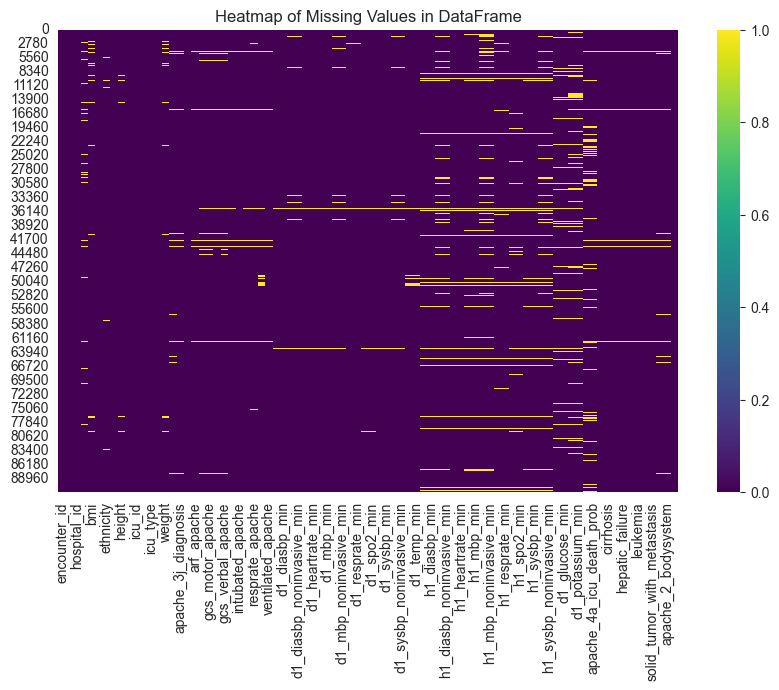

In [10]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cmap='viridis')
plt.title('Heatmap of Missing Values in DataFrame')
plt.show()

This heatmap visualizes the distribution of missing values across all features in the inpatient dataset. The x-axis represents feature columns (e.g., height, weight, blood pressure, APACHE scores), and the y-axis represents individual patient records. Yellow cells indicate missing values (NaNs), while purple cells represent available data.

Key observations:

Localized missingness: Features like h1_diasbp_noninvasive_min, h1_sysbp_noninvasive_min, and d1_resprate_min show significant missing values in specific sample ranges, indicating they may not be recorded for certain ICU patient groups.

Core identifiers are intact: Fields like encounter_id, hospital_id, and age have almost no missing values, reflecting good baseline data quality.

In [14]:
# numerical_cols
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()
print("\nNumerical Variables:")
print(numerical_cols)
print("len of numerical_cols：", len(numerical_cols))
# categorical_cols
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("\nCategorical Variables:")
print(categorical_cols)
print("len of categorical_cols：", len(categorical_cols))


Numerical Variables:
['encounter_id', 'patient_id', 'hospital_id', 'age', 'bmi', 'elective_surgery', 'height', 'icu_id', 'pre_icu_los_days', 'weight', 'apache_2_diagnosis', 'apache_3j_diagnosis', 'apache_post_operative', 'arf_apache', 'gcs_eyes_apache', 'gcs_motor_apache', 'gcs_unable_apache', 'gcs_verbal_apache', 'heart_rate_apache', 'intubated_apache', 'map_apache', 'resprate_apache', 'temp_apache', 'ventilated_apache', 'd1_diasbp_max', 'd1_diasbp_min', 'd1_diasbp_noninvasive_max', 'd1_diasbp_noninvasive_min', 'd1_heartrate_max', 'd1_heartrate_min', 'd1_mbp_max', 'd1_mbp_min', 'd1_mbp_noninvasive_max', 'd1_mbp_noninvasive_min', 'd1_resprate_max', 'd1_resprate_min', 'd1_spo2_max', 'd1_spo2_min', 'd1_sysbp_max', 'd1_sysbp_min', 'd1_sysbp_noninvasive_max', 'd1_sysbp_noninvasive_min', 'd1_temp_max', 'd1_temp_min', 'h1_diasbp_max', 'h1_diasbp_min', 'h1_diasbp_noninvasive_max', 'h1_diasbp_noninvasive_min', 'h1_heartrate_max', 'h1_heartrate_min', 'h1_mbp_max', 'h1_mbp_min', 'h1_mbp_noninva

Explore the correlationship between all numerical variables and target - hospital_death

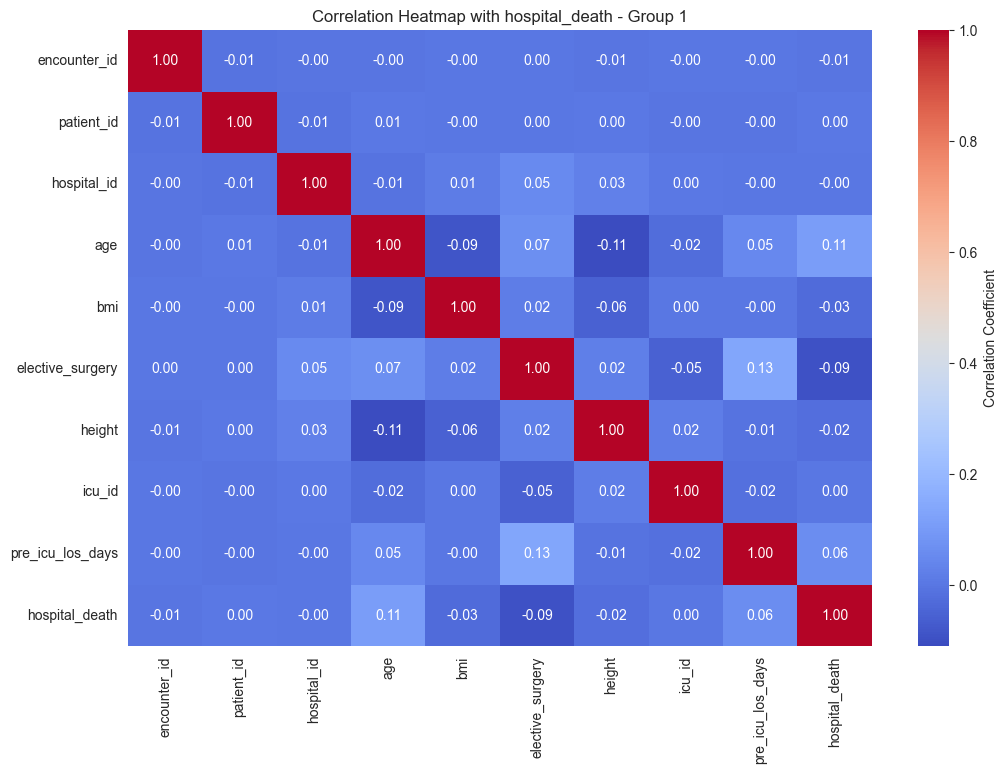

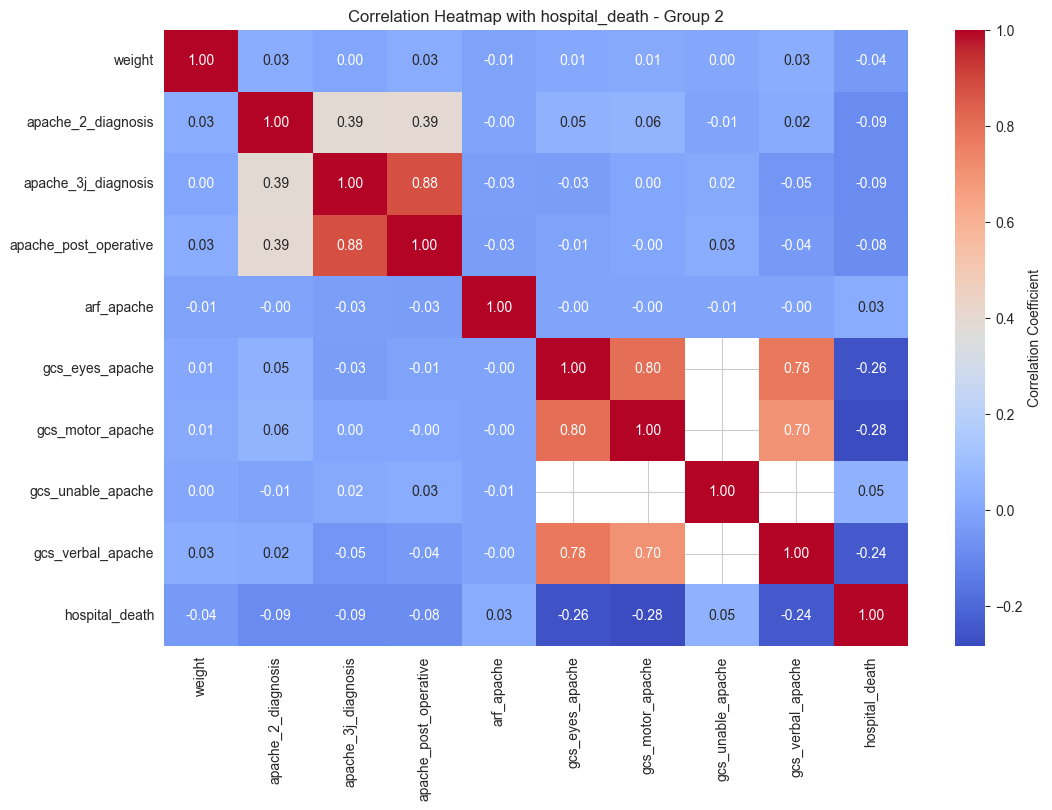

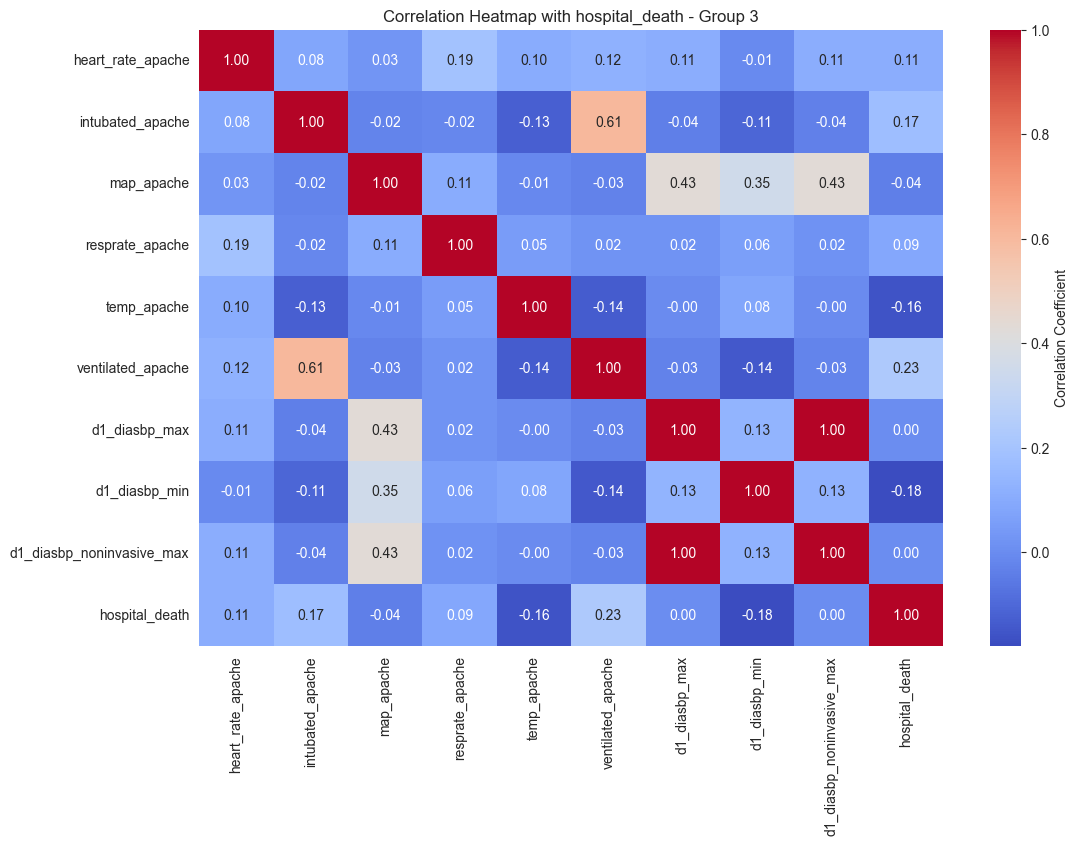

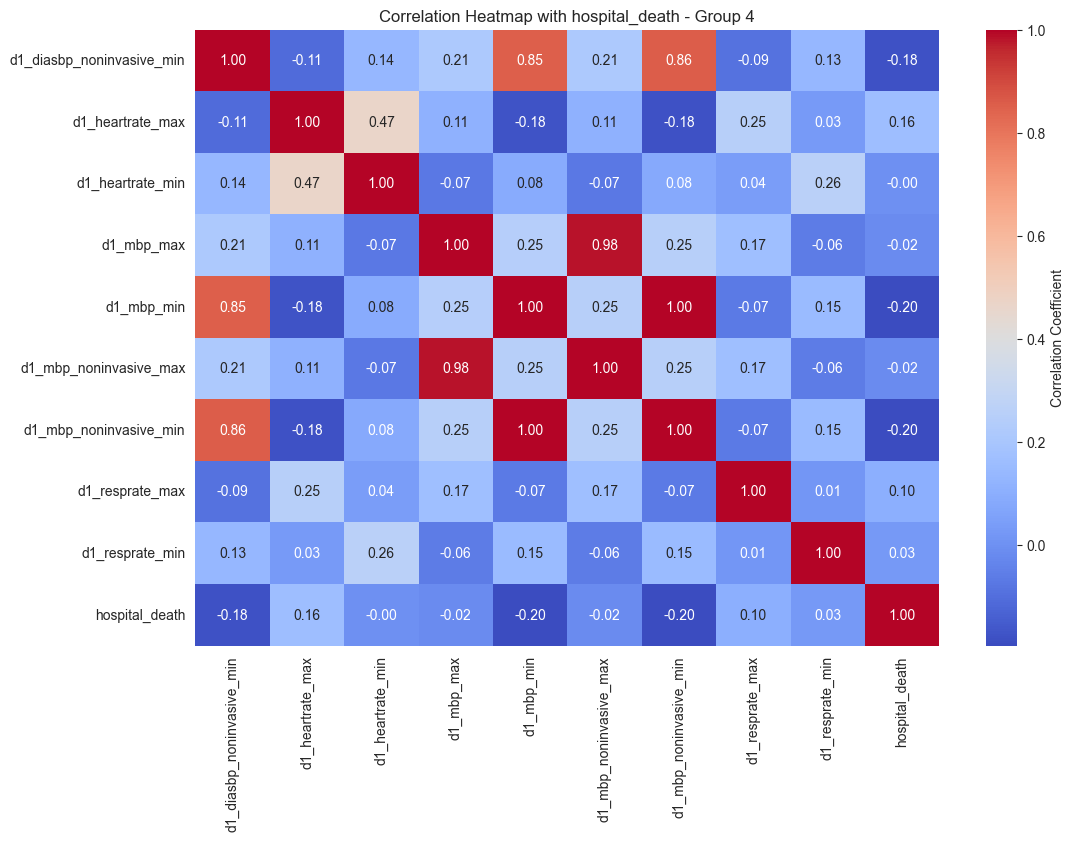

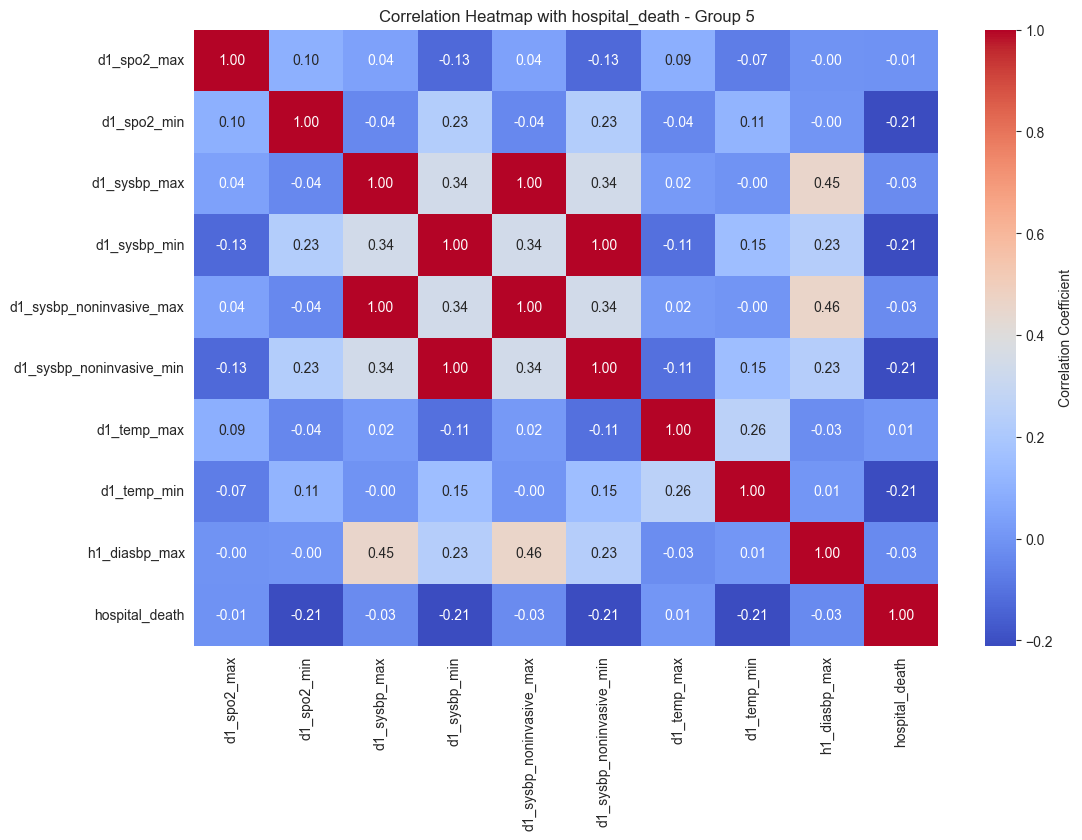

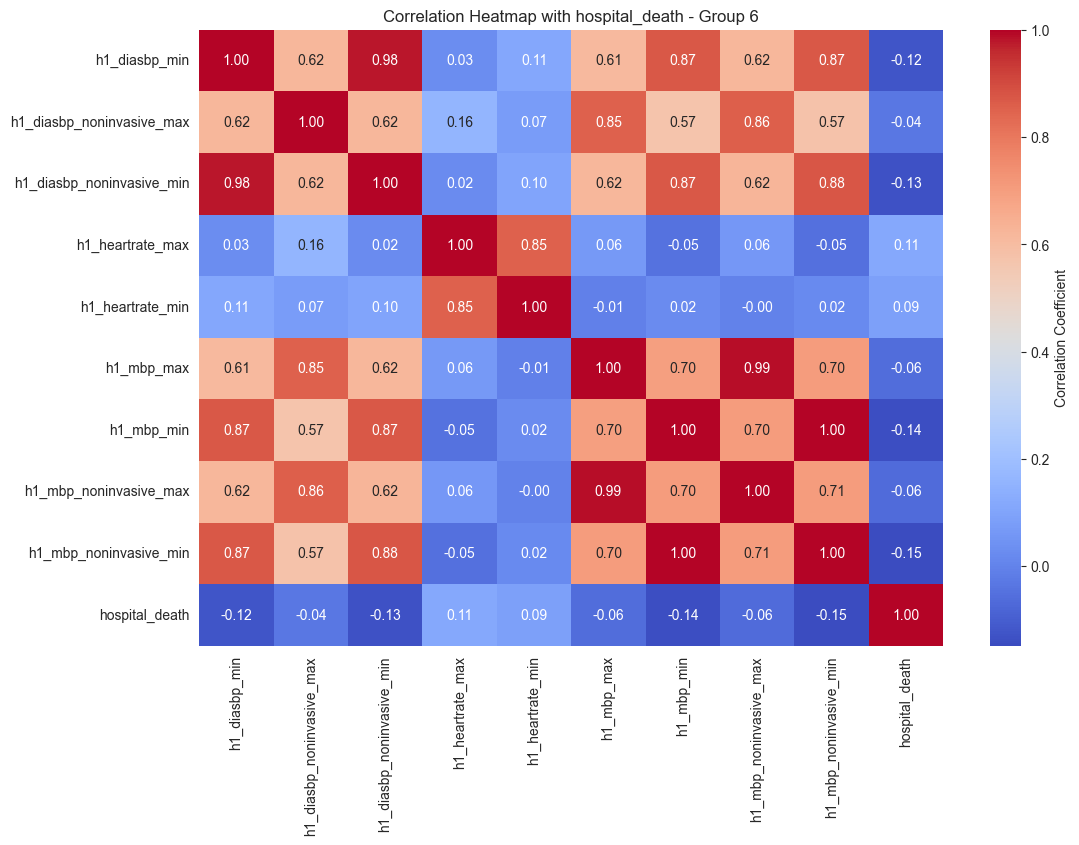

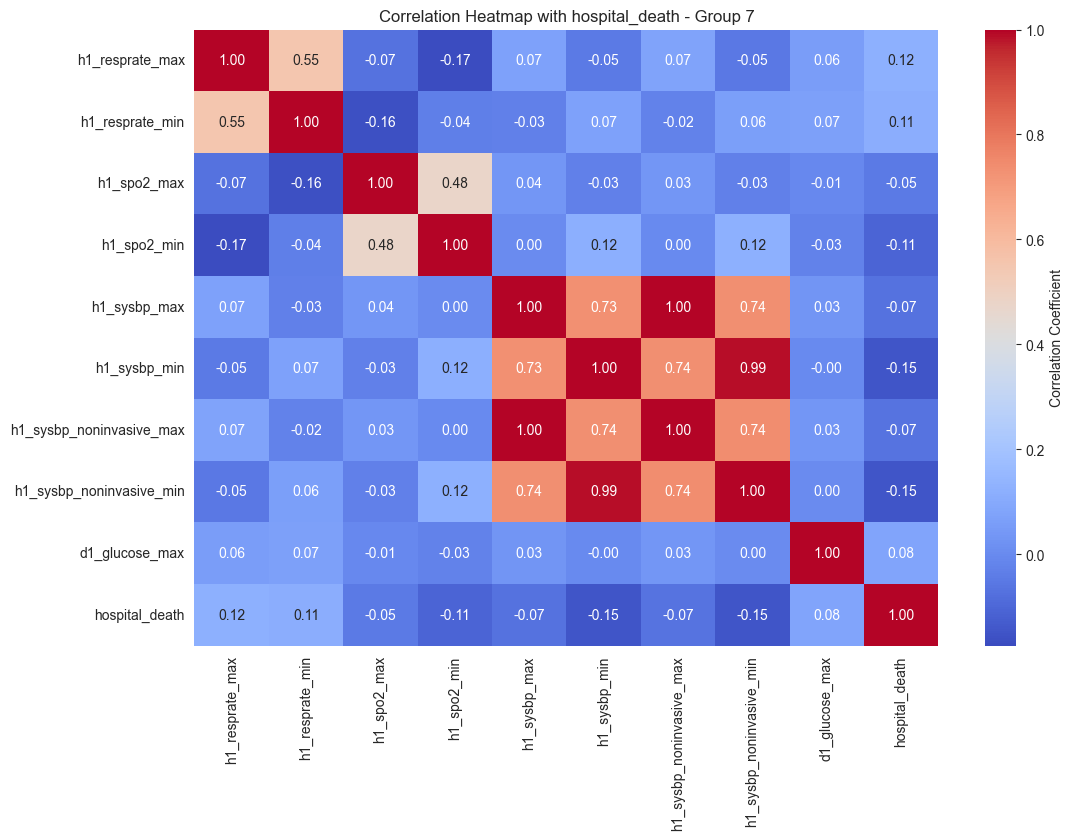

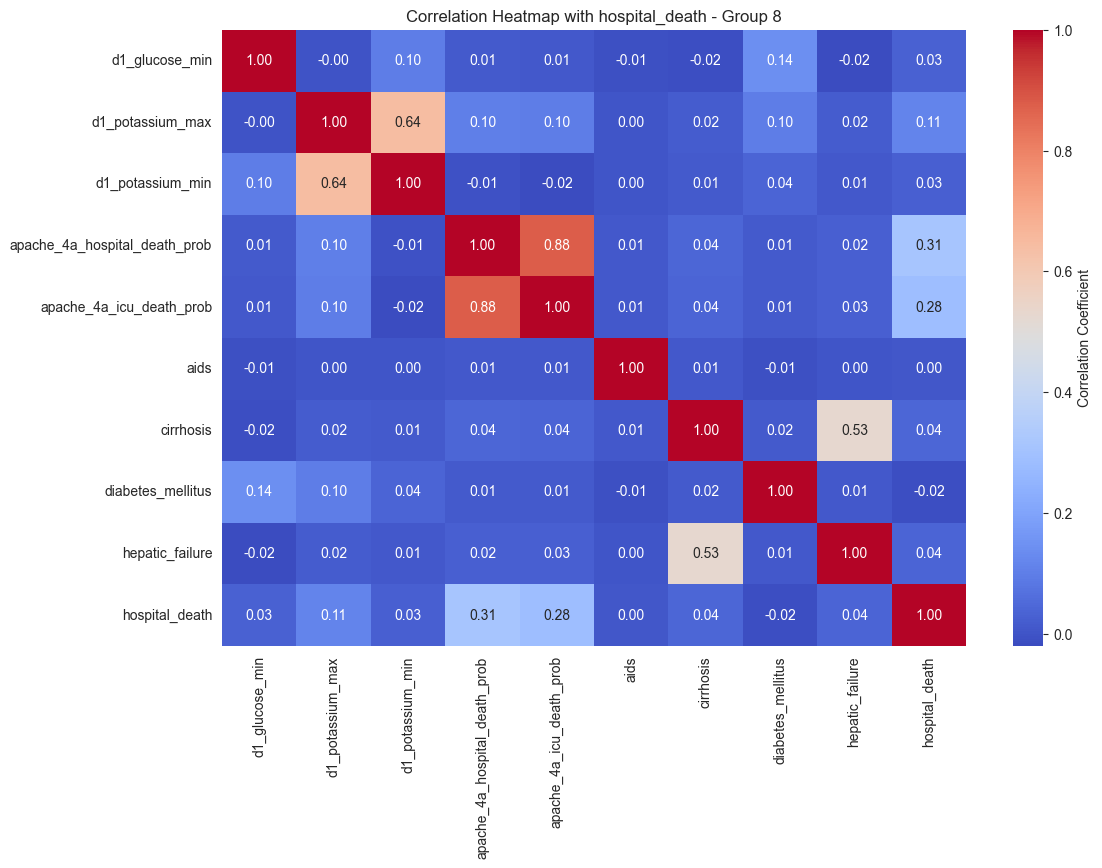

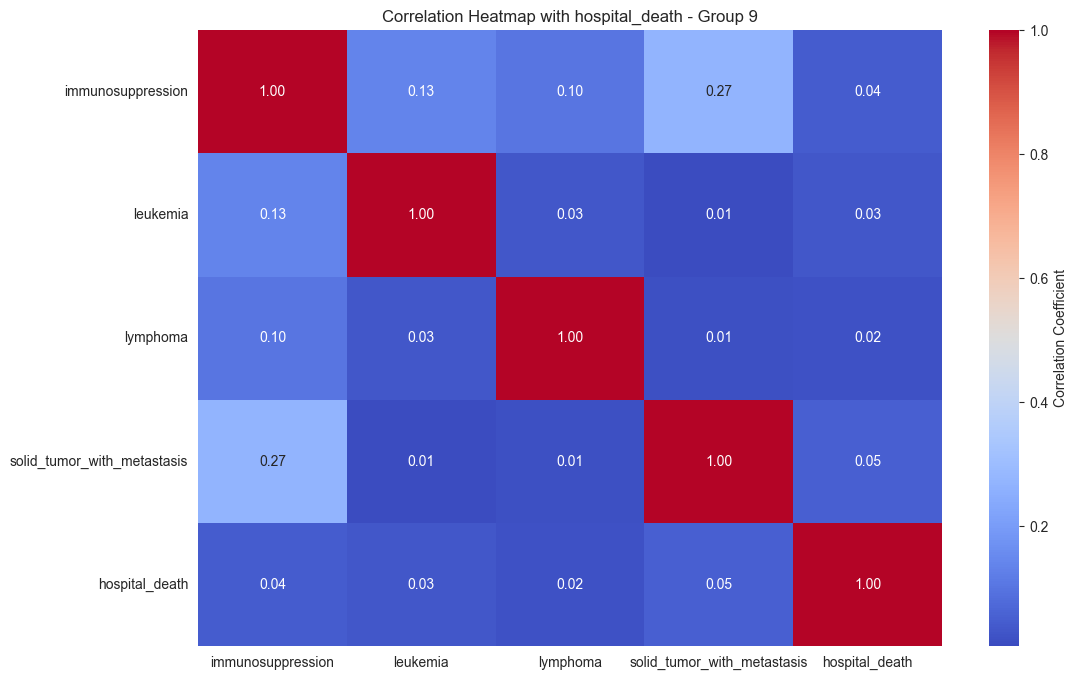

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix for all numerical features
correlation_matrix = df.select_dtypes(include=['number']).corr()

# Extract correlation values with respect to the target 'hospital_death'
hospital_death_corr = correlation_matrix['hospital_death'].drop('hospital_death').sort_values(ascending=False)

# Define the number of features per group for visualization
group_size = 9

# Get all numerical features excluding the target column
features = [col for col in df.select_dtypes(include=['number']).columns if col != 'hospital_death']

# Loop through feature groups and generate grouped heatmaps
for i in range(0, len(features), group_size):
    end_index = min(i + group_size, len(features))
    current_group = features[i:end_index]

    # Create a sub-correlation matrix including current group + 'hospital_death'
    group_corr_df = correlation_matrix.loc[current_group + ['hospital_death'], current_group + ['hospital_death']]

    # Plot the correlation heatmap for the current group
    plt.figure(figsize=(12, 8))
    sns.heatmap(group_corr_df, annot=True, cmap='coolwarm', fmt=".2f", cbar_kws={'label': 'Correlation Coefficient'})
    plt.title(f'Correlation Heatmap with hospital_death - Group {i // group_size + 1}')
    plt.show()


From the result,we can see that low correlation numerical variables contains 

 [
    'immunosuppression', 'cirrhosis', 'hepatic_failure', 'd1_glucose_min', 'leukemia', 'arf_apache',
    'd1_resprate_min', 'd1_potassium_min', 'lymphoma', 'd1_temp_max', 'patient_id', 'aids',
    'd1_diasbp_noninvasive_max', 'd1_diasbp_max', 'icu_id', 'hospital_id', 'd1_heartrate_min', 'encounter_id',
    'd1_spo2_max', 'diabetes_mellitus', 'd1_mbp_noninvasive_max', 'd1_mbp_max', 'height',
    'd1_sysbp_noninvasive_max', 'd1_sysbp_max', 'bmi', 'h1_diasbp_max', 'h1_diasbp_noninvasive_max',
    'weight', 'map_apache', 'h1_spo2_max'
]

,which means these variables will be remove from the later data processing and model training

See the top 10 correlated numerical variables

Top 10 numerical features most correlated with hospital_death:
apache_4a_hospital_death_prob    0.311043
apache_4a_icu_death_prob         0.283913
gcs_motor_apache                 0.282449
gcs_eyes_apache                  0.260373
gcs_verbal_apache                0.241044
ventilated_apache                0.228661
d1_sysbp_min                     0.210170
d1_spo2_min                      0.210100
d1_sysbp_noninvasive_min         0.209926
d1_temp_min                      0.207239
Name: hospital_death, dtype: float64


/var/folders/vy/wbc894r92vd3fwrmm1wqqfxw0000gn/T/ipykernel_87465/4153282226.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette='coolwarm', orient='h')


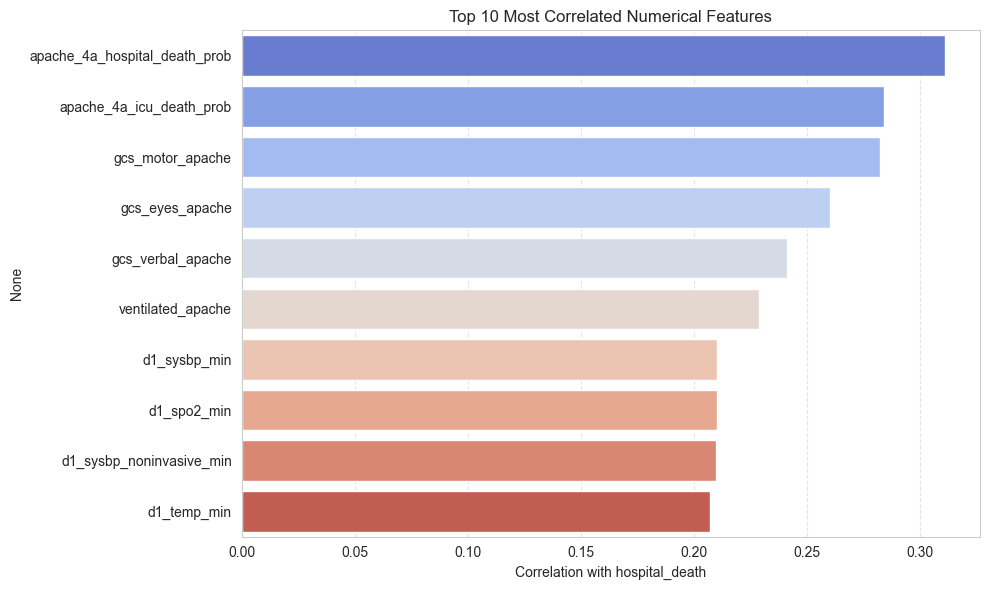

In [25]:
top_features = hospital_death_corr.abs().sort_values(ascending=False).head(10)

print("Top 10 numerical features most correlated with hospital_death:")
print(top_features)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_features.values, y=top_features.index, palette='coolwarm', orient='h')
plt.xlabel('Correlation with hospital_death')
plt.title('Top 10 Most Correlated Numerical Features')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

1.apache_4a_hospital_death_prob has the strongest correlation with hospital_death, as it represents the predicted hospital mortality from the APACHE IVa model. Its high correlation (~0.31) suggests strong predictive power.

2.apache_4a_icu_death_prob is also a highly correlated variable, indicating the predicted probability of ICU mortality. It reflects internal risk evaluation and is closely tied to patient outcome.

3.gcs_motor_apache measures motor response as part of the GCS score, where lower scores indicate impaired consciousness and higher risk of death, hence positively correlated.

4.gcs_eyes_apache reflects the patient's ability to open eyes, another part of the GCS neurological assessment. Poor scores suggest deteriorating neural response, linked to higher mortality.

5.gcs_verbal_apache represents the patient’s verbal response ability, with lower values indicating worse neurological status and increased likelihood of death.

6.ventilated_apache is a binary variable indicating mechanical ventilation usage, a common intervention in critically ill patients. Its presence typically signifies higher illness severity and correlates positively with mortality.

7.d1_sysbp_min is the minimum systolic blood pressure on day 1, where lower values suggest poor cardiovascular function, a significant marker for high mortality risk.

8.d1_spo2_min denotes the lowest oxygen saturation on the first day, and low SpO2 reflects respiratory insufficiency, directly tied to patient survival.

9.d1_sysbp_noninvasive_min is the non-invasively measured lowest systolic BP on day 1, similar in meaning to d1_sysbp_min, important for early-stage risk stratification.

10.d1_temp_min captures the lowest temperature recorded on the first day, where hypothermia can be a sign of sepsis or severe physiological dysfunction, associated with increased death risk.

                feature    chi2_stat        p_value  significant
5  apache_3j_bodysystem  1474.744498  7.181187e-311         True
2      icu_admit_source  1129.113608  3.703152e-243         True
6   apache_2_bodysystem  1117.502878  7.756726e-235         True
4              icu_type   246.619670   1.451976e-49         True
3         icu_stay_type    25.024416   3.681435e-06         True
0             ethnicity    17.867996   3.116475e-03         True
1                gender     4.473863   3.441709e-02         True


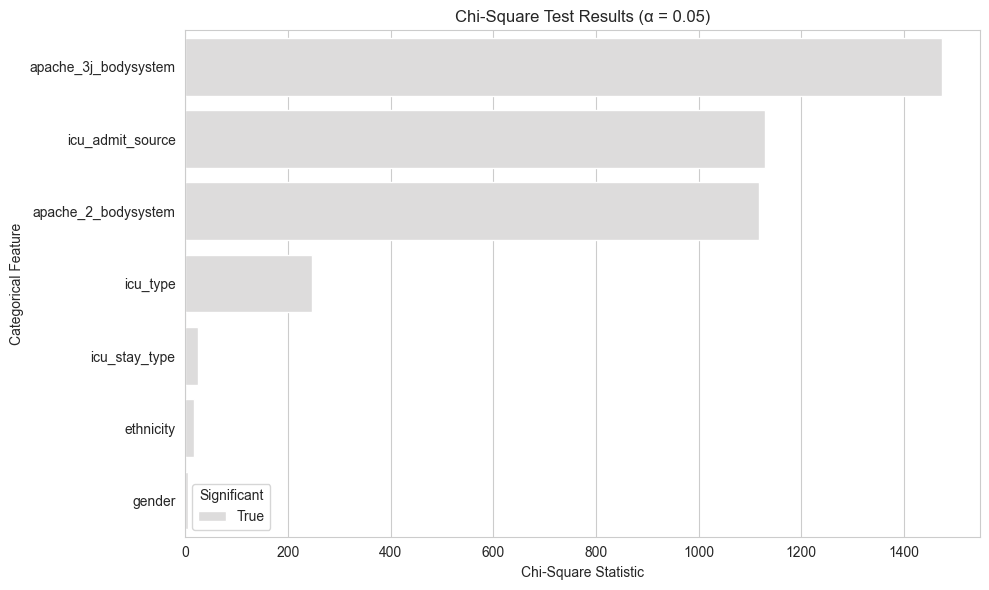

In [28]:
from scipy.stats import chi2_contingency
results = []

# Automatically identify categorical variables (object type only)
categorical_array = [col for col in df.columns
                     if col != 'hospital_death' and (df[col].dtype == 'object')]

# Perform chi-square test for each categorical feature against the target
for col in categorical_array:
    try:
        # Build a contingency table between the categorical feature and the target
        contingency_table = pd.crosstab(df[col], df['hospital_death'])

        # Apply the Chi-Square test of independence
        chi2, p, dof, expected = chi2_contingency(contingency_table)

        # Store the result: chi2 statistic, p-value, and significance flag
        results.append({
            'feature': col,
            'chi2_stat': chi2,
            'p_value': p,
            'significant': p < 0.05  # Significance level α = 0.05
        })

    except Exception as e:
        # Catch and report any errors during processing (e.g., due to missing values or small sample sizes)
        print(f"Error processing {col}: {e}")

# Convert results to DataFrame and sort by p-value ascending
result_df = pd.DataFrame(results).sort_values(by='p_value')

# Display the summary result table
print(result_df)

# Visualize the Chi-Square statistics using a horizontal bar plot
plt.figure(figsize=(10, 6))
sns.barplot(data=result_df, x='chi2_stat', y='feature', hue='significant', dodge=False, palette='coolwarm')
plt.title(f'Chi-Square Test Results (α = {0.05})')
plt.xlabel('Chi-Square Statistic')
plt.ylabel('Categorical Feature')
plt.legend(title='Significant')
plt.tight_layout()
plt.show()


All p-values are less than 0.05, indicating statistically significant associations with hospital_death.

The most strongly associated feature is apache_3j_bodysystem, followed by icu_admit_source.

Although gender is statistically significant, it has the weakest association (lowest χ² value).

Visualization:
The barplot shows Chi-Square statistics for all categorical features. The longer the bar, the stronger the relationship with hospital death. All bars are labeled as significant (True), visually reinforcing that all tested features passed the significance threshold.

See the distribution of categorical variables

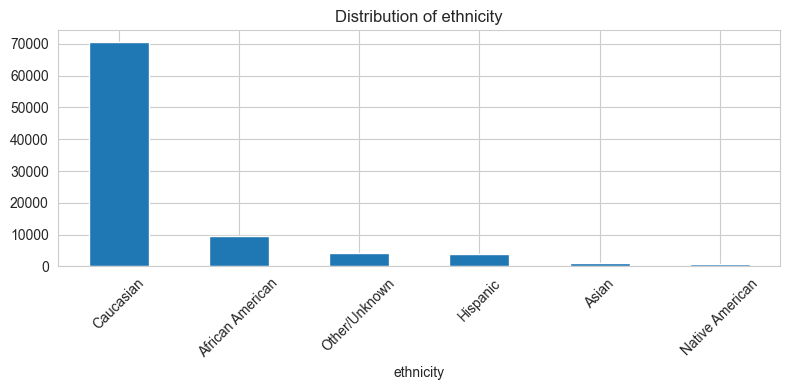

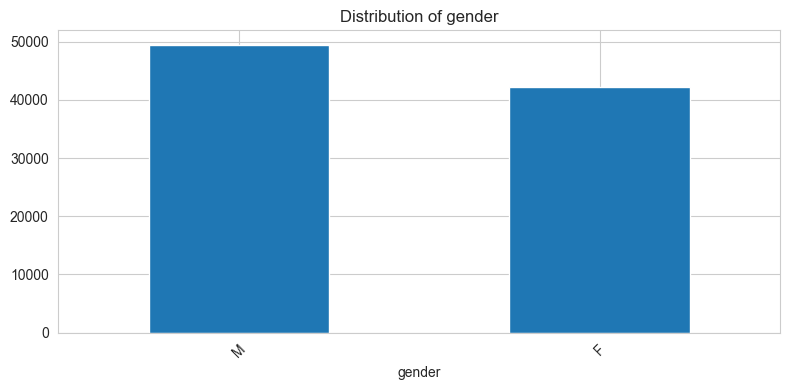

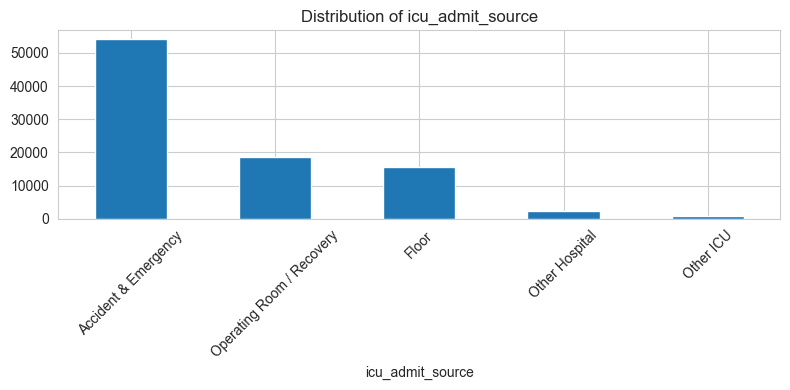

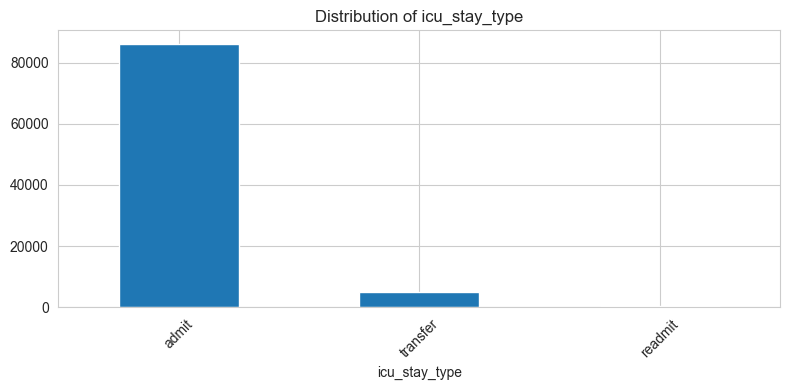

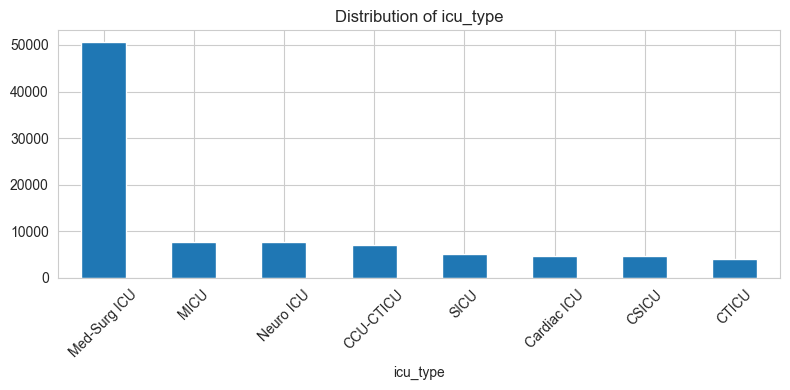

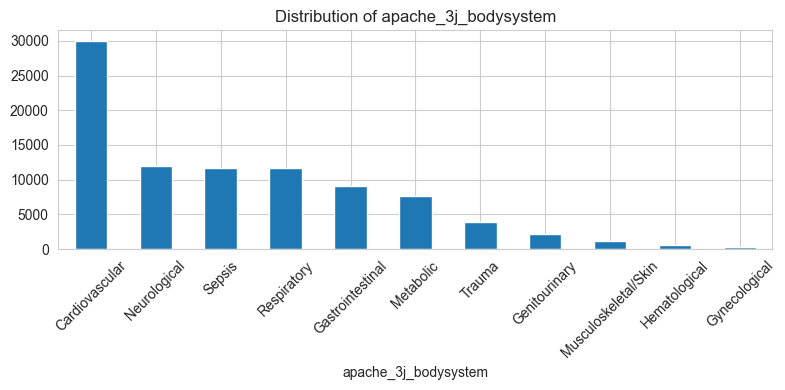

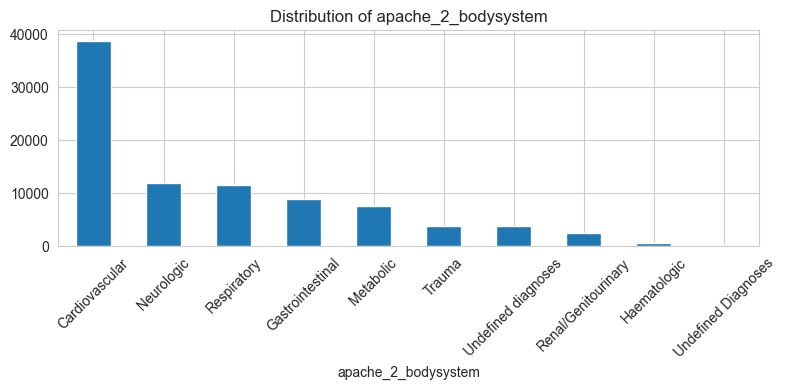

In [29]:
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    df[col].value_counts().plot(kind='bar')
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


See the distribution of hospital_death

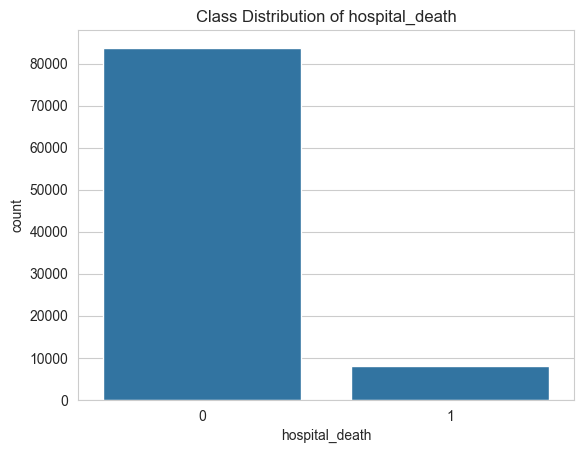

In [33]:
sns.countplot(x='hospital_death', data=df)
plt.title('Class Distribution of hospital_death')
plt.show()
